# Superstore Sales & Profitability Analysis

## Project Overview

This project analyzes sales and profitability data from a retail superstore to identify key business trends, profitable and loss-making product categories, the relationship between discounting and profitability, regional performance, and customer-level profitability.

The objective is to understand **what is driving sales and profit, where profitability is being lost, and what areas of the business may offer opportunities for improvement.**

### Key Business Questions

* Which product categories and sub-categories generate the most sales and profit?
* Which areas of the business are contributing to losses?
* How does discounting affect profitability?
* Which regions perform best and worst?
* How have sales and profit changed over time?
* How many customers are loss-making?
* What business actions could potentially improve profitability?

### Tools & Technologies

* Python
* Pandas
* NumPy
* Matplotlib
* Jupyter Notebook


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

df = pd.read_csv("dataset.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Dataset Dimensions

First, we check the number of rows and columns in the dataset.


In [2]:
df.shape

(9994, 21)

## Dataset Columns

Let's examine the available columns to understand what information is available for analysis.


In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

## Data Type Correction

The `Order Date` and `Ship Date` columns are currently stored as strings. Since date-based analysis is an important part of this project, these columns will be converted to datetime format.


In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

## Missing Value Check

We check each column for missing values before proceeding with the analysis.


In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## Statistical Overview

We use descriptive statistics to understand the distribution and range of the key numerical variables in the dataset.


In [7]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [8]:
print("Start Date:", df["Order Date"].min())
print("End Date:", df["Order Date"].max())

Start Date: 2014-01-03 00:00:00
End Date: 2017-12-30 00:00:00


## Overall Business Performance

We first calculate the total sales and profit generated across the entire dataset to establish a baseline for the analysis.


In [9]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02


In [10]:
profit_margin = (total_profit / total_sales) * 100

print(f"Overall Profit Margin: {profit_margin:.2f}%")

Overall Profit Margin: 12.47%


In [11]:
overall_summary = pd.DataFrame({
    "Metric": ["Total Sales", "Total Profit", "Profit Margin"],
    "Value": [
        f"${total_sales:,.2f}",
        f"${total_profit:,.2f}",
        f"{profit_margin:.2f}%"
    ]
})

overall_summary

,Metric,Value
0,Total Sales,"$2,297,200.86"
1,Total Profit,"$286,397.02"
2,Profit Margin,12.47%


### Key Insight

The business generated approximately **\$2.30 million in sales** and **\$286,397 in profit**, resulting in an overall profit margin of approximately **12.47%**. This provides the baseline against which category, regional, customer, and time-based performance can be evaluated.


## Category Performance

We compare total Sales and Profit across the three product categories to identify which categories contribute most to revenue and profitability.


In [12]:
category_summary = (
    df.groupby("Category")[["Sales", "Profit"]]
    .sum()
)

category_summary["Profit Margin"] = (
    category_summary["Profit"] /
    category_summary["Sales"]
) * 100

category_summary

,Sales,Profit,Profit Margin
Category,,,
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


In [13]:
category_display = category_summary.copy()

category_display["Sales"] = category_display["Sales"].map(
    lambda x: f"${x:,.2f}"
)

category_display["Profit"] = category_display["Profit"].map(
    lambda x: f"${x:,.2f}"
)

category_display["Profit Margin"] = category_display["Profit Margin"].map(
    lambda x: f"{x:.2f}%"
)

category_display

,Sales,Profit,Profit Margin
Category,,,
Furniture,"$741,999.80","$18,451.27",2.49%
Office Supplies,"$719,047.03","$122,490.80",17.04%
Technology,"$836,154.03","$145,454.95",17.40%


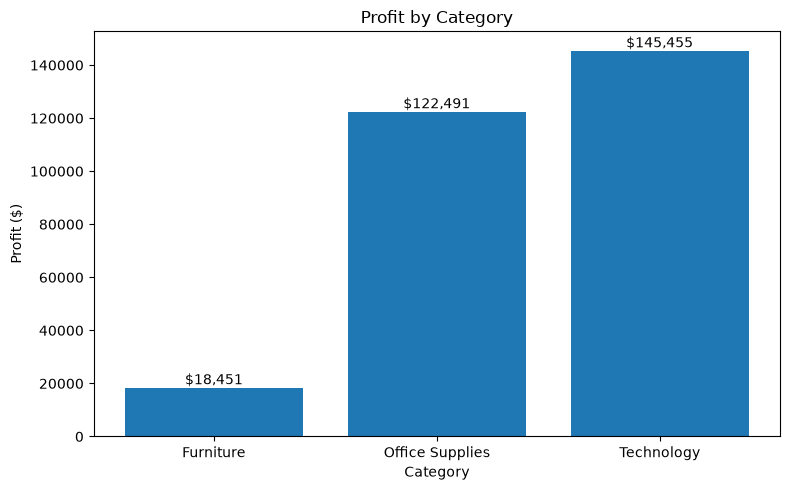

In [14]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    category_summary.index,
    category_summary["Profit"]
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit ($)")

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Key Insight

**Technology generates the highest profit, while Furniture generates the lowest profit despite having sales comparable to the other categories. Furniture's profit margin is only about 2.49%, compared with approximately 17% for both Technology and Office Supplies. This indicates that the main issue with Furniture is not sales volume but poor profitability.**


## Furniture Sub-Category Analysis

Since Furniture has substantially lower profitability than the other categories, we drill down into its sub-categories to identify the sources of profit and loss.


In [15]:
furniture_summary = (
    df[df["Category"] == "Furniture"]
    .groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
)
furniture_summary["Profit Margin"] = (
    furniture_summary["Profit"] / furniture_summary["Sales"]
) * 100


furniture_summary

,Sales,Profit,Profit Margin
Sub-Category,,,
Bookcases,114879.9963,-3472.5560,-3.022768
Chairs,328449.1030,26590.1663,8.095673
Furnishings,91705.1640,13059.1436,14.240358
Tables,206965.5320,-17725.4811,-8.564460


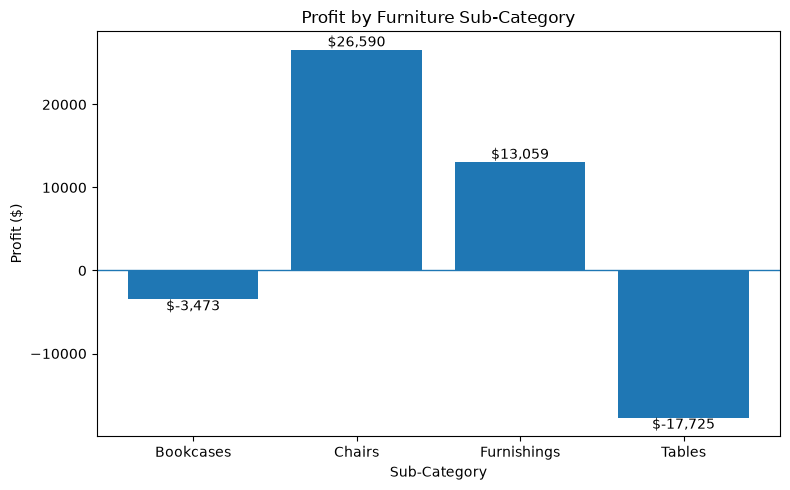

In [16]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    furniture_summary.index,
    furniture_summary["Profit"]
)

plt.title("Profit by Furniture Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit ($)")
plt.axhline(0, linewidth=1)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.tight_layout()
plt.show()

### Key Insight

Furniture's weak profitability is concentrated in **Bookcases and Tables**, both of which generate negative profits. **Tables are the largest source of loss at approximately \$17.7K**, while Bookcases lose approximately \$3.5K. In contrast, Chairs and Furnishings are profitable, with Chairs generating the highest profit within the Furniture category.

This suggests that the profitability problem within Furniture is concentrated in specific sub-categories rather than being a problem across the entire category.


## Discount and Profitability

We investigate the relationship between discount levels and profitability to determine whether higher discounts are associated with lower profits.


In [17]:
avg_profit_discount = df.groupby("Discount")["Profit"].mean()
avg_profit_discount

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

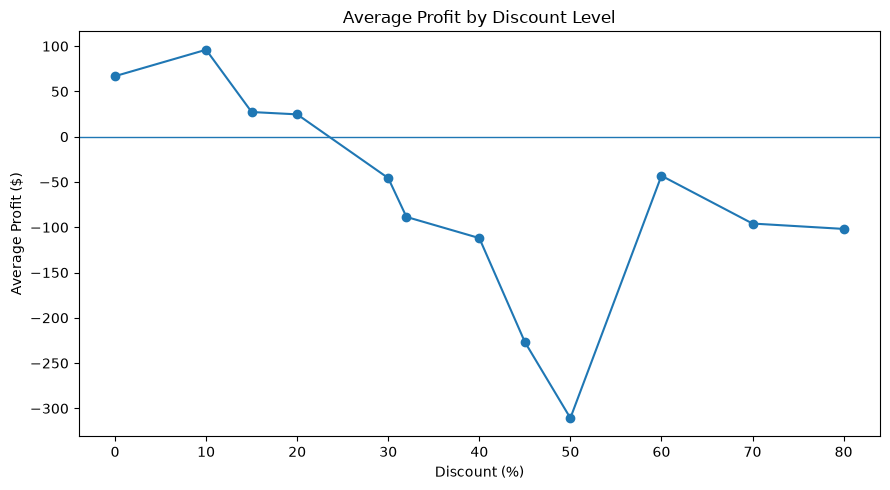

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    avg_profit_discount.index * 100,
    avg_profit_discount.values,
    marker="o"
)

plt.axhline(0, linewidth=1)

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount (%)")
plt.ylabel("Average Profit ($)")

plt.tight_layout()
plt.show()

In [19]:
discount_profit_corr = df["Discount"].corr(df["Profit"])

print(f"Correlation between Discount and Profit: {discount_profit_corr:.3f}")

Correlation between Discount and Profit: -0.219


### Key Insight

Profitability shows a clear negative relationship with discounting. Average profit remains positive at discounts up to approximately **20%**, but becomes negative at higher discount levels. The correlation between Discount and Profit is approximately **-0.219**, indicating a negative association between the two variables.

This suggests that aggressive discounting may be an important contributor to profitability problems, particularly in loss-making areas of the business.


## Discount by Furniture Sub-Category

We compare average discount levels across Furniture sub-categories to investigate whether higher discounting is associated with the loss-making sub-categories.


In [20]:
furniture_analysis = (
    df[df["Category"] == "Furniture"]
    .groupby("Sub-Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Avg_Discount=("Discount", "mean")
    )
)

furniture_analysis["Profit_Margin"] = (
    furniture_analysis["Profit"] /
    furniture_analysis["Sales"]
) * 100

furniture_analysis

,Sales,Profit,Avg_Discount,Profit_Margin
Sub-Category,,,,
Bookcases,114879.9963,-3472.5560,0.211140,-3.022768
Chairs,328449.1030,26590.1663,0.170178,8.095673
Furnishings,91705.1640,13059.1436,0.138349,14.240358
Tables,206965.5320,-17725.4811,0.261285,-8.564460


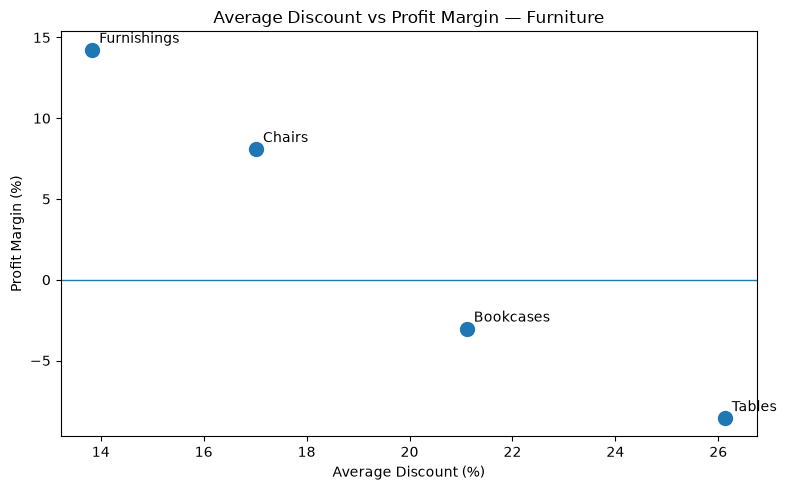

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    furniture_analysis["Avg_Discount"] * 100,
    furniture_analysis["Profit_Margin"],
    s=100
)

for subcategory in furniture_analysis.index:
    plt.annotate(
        subcategory,
        (
            furniture_analysis.loc[subcategory, "Avg_Discount"] * 100,
            furniture_analysis.loc[subcategory, "Profit_Margin"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.axhline(0, linewidth=1)

plt.title("Average Discount vs Profit Margin — Furniture")
plt.xlabel("Average Discount (%)")
plt.ylabel("Profit Margin (%)")

plt.tight_layout()
plt.show()

### Key Insight

Within the Furniture category, the loss-making sub-categories receive higher average discounts than the profitable sub-categories. **Tables have the highest average discount at approximately 26.13% and the lowest profit margin at -8.56%, while Bookcases have an average discount of approximately 21.11% and a negative profit margin of -3.02%.** In contrast, Furnishings and Chairs receive lower average discounts and remain profitable.

This strengthens the evidence that excessive discounting is an important factor associated with Furniture's poor profitability.


## Yearly Performance Analysis

We analyze yearly Sales and Profit to understand the overall growth of the business and determine whether profitability has improved over time.


## Creating the Year Column

To perform yearly analysis, we derive the year from the `Order Date` column and store it in a new `Year` column.

In [22]:
df["Year"] = df["Order Date"].dt.year

In [23]:
yearly_summary = (
    df.groupby("Year")[["Sales", "Profit"]]
    .sum()
)

yearly_summary

,Sales,Profit
Year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


In [24]:
yearly_summary["Sales Growth %"] = (
    yearly_summary["Sales"].pct_change() * 100
)

yearly_summary["Profit Growth %"] = (
    yearly_summary["Profit"].pct_change() * 100
)

yearly_summary

,Sales,Profit,Sales Growth %,Profit Growth %
Year,,,,
2014,484247.4981,49543.9741,NaN,NaN
2015,470532.5090,61618.6037,-2.832227,24.371540
2016,609205.5980,81795.1743,29.471521,32.744284
2017,733215.2552,93439.2696,20.355962,14.235675


In [25]:
yearly_summary["Profit Margin"] = (
    yearly_summary["Profit"] /
    yearly_summary["Sales"]
) * 100

yearly_summary

,Sales,Profit,Sales Growth %,Profit Growth %,Profit Margin
Year,,,,,
2014,484247.4981,49543.9741,NaN,NaN,10.231126
2015,470532.5090,61618.6037,-2.832227,24.371540,13.095504
2016,609205.5980,81795.1743,29.471521,32.744284,13.426530
2017,733215.2552,93439.2696,20.355962,14.235675,12.743771


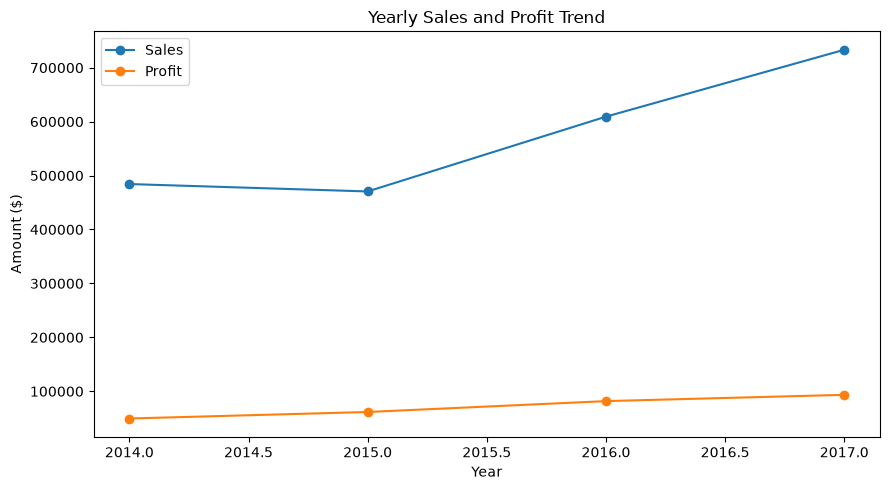

In [26]:
plt.figure(figsize=(9, 5))

plt.plot(
    yearly_summary.index,
    yearly_summary["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    yearly_summary.index,
    yearly_summary["Profit"],
    marker="o",
    label="Profit"
)

plt.title("Yearly Sales and Profit Trend")
plt.xlabel("Year")
plt.ylabel("Amount ($)")
plt.legend()

plt.tight_layout()
plt.show()

### Key Insight

Sales generally increased over the four-year period, reaching their highest level in **2017**. However, profit growth was not always proportional to sales growth. Profit margin improved from **10.23% in 2014 to 13.43% in 2016**, before declining to **12.74% in 2017** despite sales reaching their highest level.

The decline in profit margin during 2017 suggests that the business's strong sales growth was accompanied by some deterioration in profitability.


In [27]:
df["Year-Month"] = df["Order Date"].dt.to_period("M")

In [28]:
monthly_summary = (
    df.groupby("Year-Month")[["Sales", "Profit"]]
    .sum()
)

monthly_summary.head()

,Sales,Profit
Year-Month,,
2014-01,14236.895,2450.1907
2014-02,4519.892,862.3084
2014-03,55691.009,498.7299
2014-04,28295.345,3488.8352
2014-05,23648.287,2738.7096


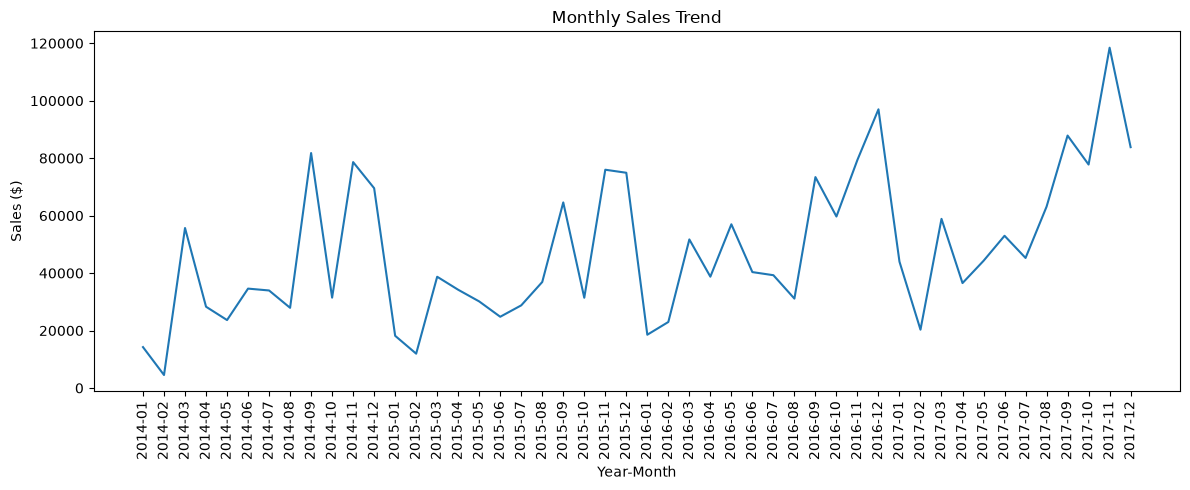

In [29]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary["Sales"]
)

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Sales ($)")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

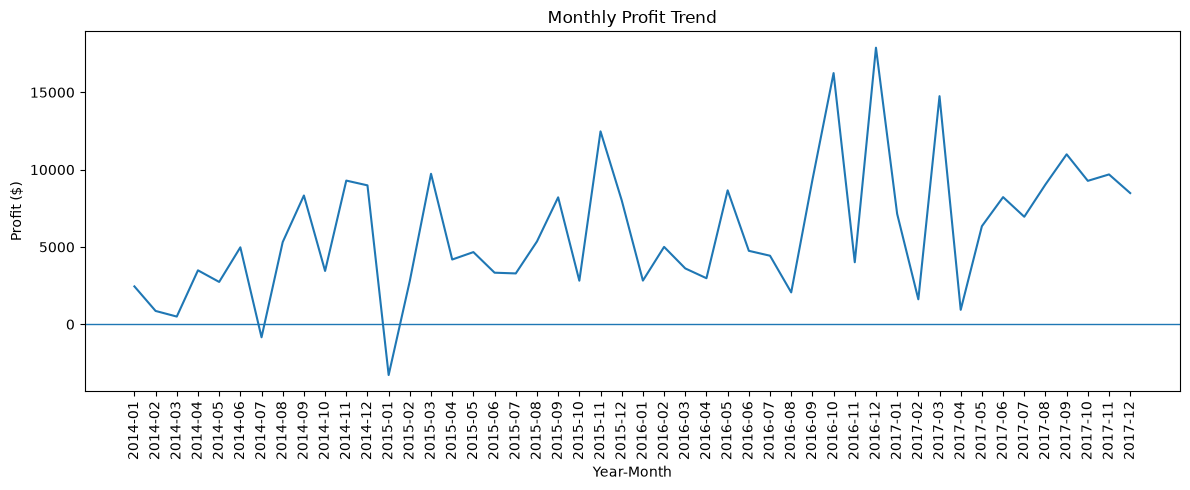

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary["Profit"]
)

plt.axhline(0, linewidth=1)

plt.title("Monthly Profit Trend")
plt.xlabel("Year-Month")
plt.ylabel("Profit ($)")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [31]:
lowest_profit_months = (
    monthly_summary
    .sort_values("Profit")
    .head(5)
)

lowest_profit_months

,Sales,Profit
Year-Month,,
2015-01,18174.0756,-3281.0070
2014-07,33946.3930,-841.4826
2014-03,55691.0090,498.7299
2014-02,4519.8920,862.3084
2017-04,36521.5361,933.2900


In [32]:
lowest_sales_months = (
    monthly_summary
    .sort_values("Sales")
    .head(5)
)

lowest_sales_months

,Sales,Profit
Year-Month,,
2014-02,4519.8920,862.3084
2015-02,11951.4110,2813.8508
2014-01,14236.8950,2450.1907
2015-01,18174.0756,-3281.0070
2016-01,18542.4910,2824.8233


### Key Insight

Monthly performance shows considerable variation rather than a simple linear trend. **January 2015 was the worst-performing month, generating approximately 3.28K USD in losses, followed by July 2014 with a loss of approximately 841 USD.** March 2014 is also notable because it generated approximately **55.7K USD in Sales but only 499 USD in Profit**, indicating very weak profitability despite relatively strong sales.

The lowest-sales months were concentrated mainly in January and February, suggesting some seasonal variation in sales. However, low sales do not necessarily result in losses, indicating that factors beyond sales volume, such as discounting and product mix, also influence monthly profitability.


## Regional Performance Analysis

We compare Sales, Profit, and Profit Margin across regions to identify geographic differences in business performance and profitability.


In [33]:
region_summary = (
    df.groupby("Region")[["Sales", "Profit"]]
    .sum()
)

region_summary

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


In [34]:
region_summary["Profit Margin"] = (
    region_summary["Profit"] /
    region_summary["Sales"]
) * 100

region_summary

,Sales,Profit,Profit Margin
Region,,,
Central,501239.8908,39706.3625,7.921629
East,678781.2400,91522.7800,13.483399
South,391721.9050,46749.4303,11.934342
West,725457.8245,108418.4489,14.944831


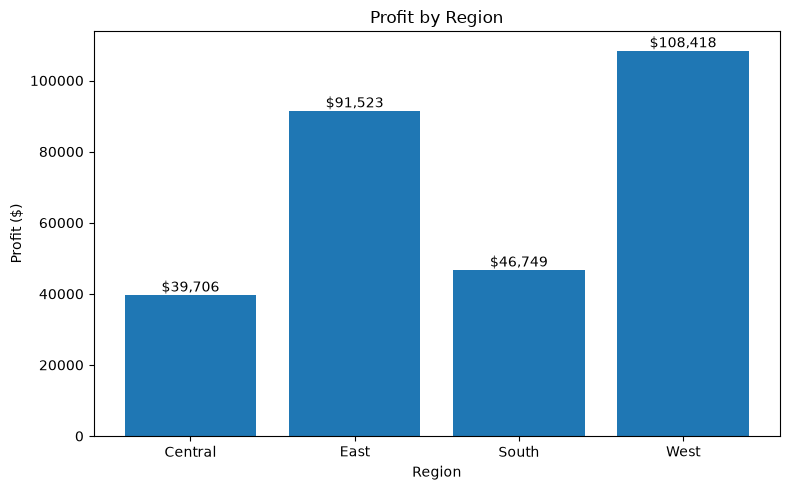

In [35]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    region_summary.index,
    region_summary["Profit"]
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit ($)")

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [36]:
region_display = region_summary.copy()

region_display["Sales"] = region_display["Sales"].map(
    lambda x: f"${x:,.2f}"
)

region_display["Profit"] = region_display["Profit"].map(
    lambda x: f"${x:,.2f}"
)

region_display["Profit Margin"] = region_display["Profit Margin"].map(
    lambda x: f"{x:.2f}%"
)

region_display

,Sales,Profit,Profit Margin
Region,,,
Central,"$501,239.89","$39,706.36",7.92%
East,"$678,781.24","$91,522.78",13.48%
South,"$391,721.91","$46,749.43",11.93%
West,"$725,457.82","$108,418.45",14.94%


### Key Insight

**West is the strongest-performing region**, generating the highest Sales and Profit, along with the highest profit margin of approximately **14.94%**. In contrast, **Central has the weakest profitability**, with a profit margin of only **7.92%** despite generating more Sales than South.

This shows that higher Sales do not necessarily translate into higher profitability, with regional differences in margins indicating that factors such as discounting and product mix may influence regional performance.


## Customer Profitability Analysis

We analyze customer-level Sales and Profit to identify the most profitable customers and customers generating significant losses.


In [37]:
customer_summary = (
    df.groupby("Customer Name")[["Sales", "Profit"]]
    .sum()
)

customer_summary.head()


,Sales,Profit
Customer Name,,
Aaron Bergman,886.156,129.3465
Aaron Hawkins,1744.700,365.2152
Aaron Smayling,3050.692,-253.5746
Adam Bellavance,7755.620,2054.5885
Adam Hart,3250.337,281.1890


In [38]:
top_profitable_customers = (
    customer_summary
    .sort_values("Profit", ascending=False)
    .head(10)
)

top_profitable_customers

,Sales,Profit
Customer Name,,
Tamara Chand,19052.218,8981.3239
Raymond Buch,15117.339,6976.0959
Sanjit Chand,14142.334,5757.4119
Hunter Lopez,12873.298,5622.4292
Adrian Barton,14473.571,5444.8055
Tom Ashbrook,14595.620,4703.7883
Christopher Martinez,8954.020,3899.8904
Keith Dawkins,8181.256,3038.6254
Andy Reiter,6608.448,2884.6208


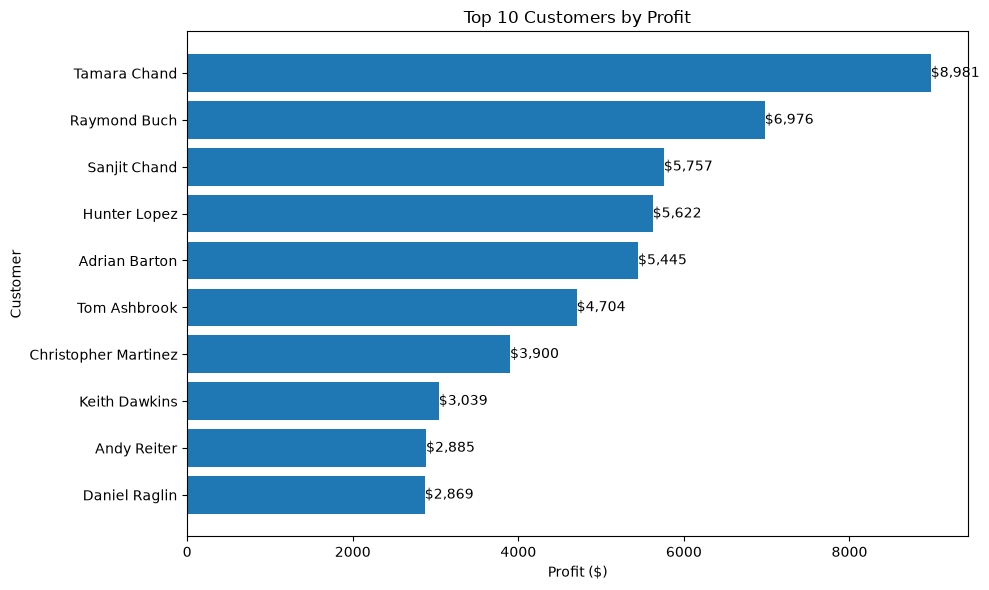

In [39]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_profitable_customers.index[::-1],
    top_profitable_customers["Profit"][::-1]
)

plt.title("Top 10 Customers by Profit")
plt.xlabel("Profit ($)")
plt.ylabel("Customer")

for bar in bars:
    value = bar.get_width()
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [40]:
loss_making_customers = (
    customer_summary[customer_summary["Profit"] < 0]
    .sort_values("Profit")
    .head(10)
)

loss_making_customers

,Sales,Profit
Customer Name,,
Cindy Stewart,5690.055,-6626.3895
Grant Thornton,9351.212,-4108.6589
Luke Foster,3930.509,-3583.9770
Sharelle Roach,3233.481,-3333.9144
Henry Goldwyn,3247.642,-2797.9635
Nathan Cano,2218.990,-2204.8072
Sean Braxton,8057.891,-2082.7451
Sean Miller,25043.050,-1980.7393
Christine Phan,5888.275,-1850.3029


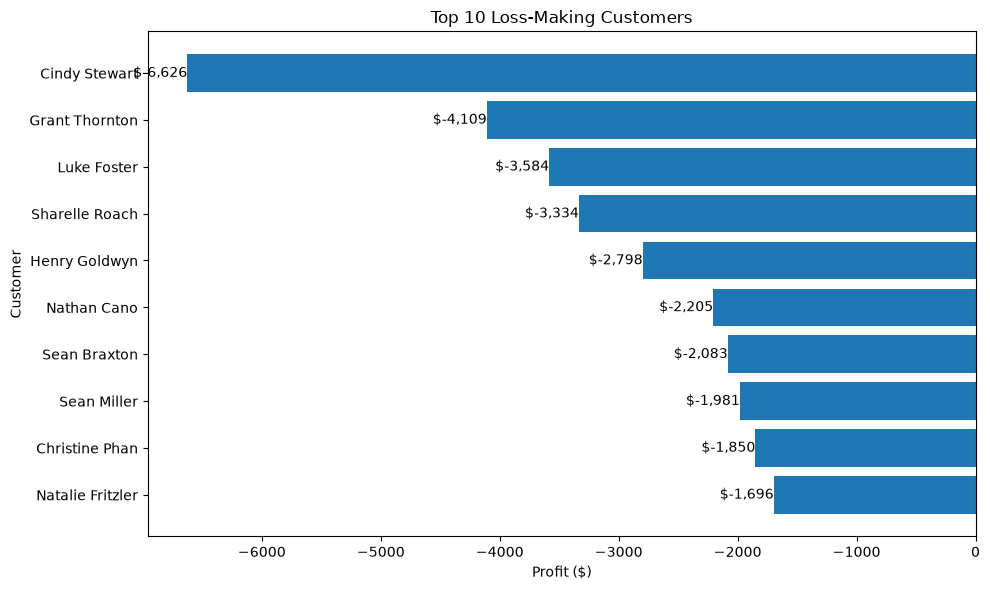

In [41]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    loss_making_customers.index[::-1],
    loss_making_customers["Profit"][::-1]
)

plt.title("Top 10 Loss-Making Customers")
plt.xlabel("Profit ($)")
plt.ylabel("Customer")

for bar in bars:
    value = bar.get_width()
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center",
        ha="right"
    )

plt.tight_layout()
plt.show()

In [42]:
loss_making_count = (
    customer_summary["Profit"] < 0
).sum()

print("Number of loss-making customers:", loss_making_count)

Number of loss-making customers: 155


In [43]:
customer_summary["Loss-Making"] = (
    customer_summary["Profit"] < 0
)

In [44]:
customer_discount = (
    df.groupby("Customer Name")["Discount"]
    .mean()
)

customer_analysis = customer_summary.copy()

customer_analysis["Avg Discount"] = customer_discount

customer_analysis.groupby("Loss-Making")[
    ["Avg Discount", "Profit"]
].mean()

,Avg Discount,Profit
Loss-Making,,
False,0.137891,560.535260
True,0.238119,-459.512738


### Key Insight

Customer-level analysis shows that profitability is concentrated among a smaller group of customers, while a significant number of customers generate losses. The analysis identified **155 loss-making customers**. More importantly, loss-making customers receive substantially higher average discounts of approximately **23.81%**, compared with **13.79%** for profitable customers.

This reinforces the negative relationship between discounting and profitability observed earlier and suggests that customer-level discount practices should be reviewed, particularly for customers consistently generating losses.


## Executive Summary

This section consolidates the key findings from the exploratory analysis into a concise business summary.


In [45]:
kpi_summary = {
    "Total Sales": total_sales,
    "Total Profit": total_profit,
    "Profit Margin": profit_margin,
    "Best Category": category_summary["Profit"].idxmax(),
    "Worst Category": category_summary["Profit"].idxmin(),
    "Best Region": region_summary["Profit"].idxmax(),
    "Worst Region by Profit": region_summary["Profit"].idxmin(),
    "Loss-Making Customers": loss_making_count
}

kpi_summary

{'Total Sales': np.float64(2297200.8603),
 'Total Profit': np.float64(286397.0217),
 'Profit Margin': np.float64(12.467217240315605),
 'Best Category': 'Technology',
 'Worst Category': 'Furniture',
 'Best Region': 'West',
 'Worst Region by Profit': 'Central',
 'Loss-Making Customers': np.int64(155)}

In [46]:
kpi_display = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Profit Margin",
        "Best Category",
        "Worst Category",
        "Best Region",
        "Worst Region by Profit",
        "Loss-Making Customers"
    ],
    "Value": [
        f"{total_sales:,.2f} USD",
        f"{total_profit:,.2f} USD",
        f"{profit_margin:.2f}%",
        kpi_summary["Best Category"],
        kpi_summary["Worst Category"],
        kpi_summary["Best Region"],
        kpi_summary["Worst Region by Profit"],
        str(loss_making_count)
    ]
})

kpi_display

,Metric,Value
0,Total Sales,"2,297,200.86 USD"
1,Total Profit,"286,397.02 USD"
2,Profit Margin,12.47%
3,Best Category,Technology
4,Worst Category,Furniture
5,Best Region,West
6,Worst Region by Profit,Central
7,Loss-Making Customers,155


### Key Business Findings

* **Technology** is the strongest category in terms of both Sales and Profit.
* **Furniture** generates Sales comparable to the other categories but produces substantially lower Profit.
* Within Furniture, **Tables and Bookcases are loss-making**, with Tables being the largest source of loss.
* Higher discount levels are consistently associated with lower profitability. Average profit becomes negative at higher discount levels, particularly above approximately **20%**.
* Loss-making customers receive substantially higher average discounts (**23.81%**) than profitable customers (**13.79%**).
* **West** is the strongest region in both Sales and Profit, while **Central** has the weakest Profit Margin.
* Sales generally increased over the years, but **Profit Margin declined from 13.43% in 2016 to 12.74% in 2017** despite record Sales.
* Monthly performance varies considerably, with **January 2015** being the worst-performing month and **July 2014** also generating a loss.


### Business Recommendations

**1. Review discounting strategy**

The analysis shows a negative association between discount levels and profitability. Discount policies should be reviewed, particularly at higher discount levels where average profitability becomes negative.

**2. Reassess Tables and Bookcases**

Tables and Bookcases generate negative profits despite contributing meaningful Sales. Pricing, discount levels, procurement costs, and product-level margins should be investigated before continuing aggressive sales of these products.

**3. Protect profitable categories**

Technology and Office Supplies generate substantially stronger profits than Furniture. The business should continue supporting these categories while ensuring that growth does not come at the expense of margin.

**4. Investigate Central region**

Central generates reasonable Sales but has the lowest Profit Margin among the four regions. Regional discounting, product mix, and operating costs should be examined to identify the source of the weaker margin.

**5. Monitor profitable growth**

Although Sales reached their highest level in 2017, Profit Margin declined compared with 2016. Future growth should therefore be evaluated using both Sales and Profit Margin rather than Sales alone.


## Conclusion

The analysis shows that the business achieved strong overall Sales growth during the period, but profitability varied considerably across categories, regions, customers, and discount levels.

Technology emerged as the strongest category, while Furniture showed a significant profitability problem despite generating comparable Sales. Within Furniture, Tables and Bookcases were responsible for negative profits, and these sub-categories also had higher average discount levels.

The analysis also found a consistent negative association between discounting and profitability. Loss-making customers received substantially higher average discounts than profitable customers, providing further evidence that discount management deserves attention.

Overall, the analysis suggests that future growth should focus not only on increasing Sales but also on protecting Profit Margins through better discounting, improved product-level profitability, and closer monitoring of underperforming regions and customers.
